In [1]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import f1_score, make_scorer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.base import clone
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from imblearn.pipeline import Pipeline
from sklearn.feature_selection import SequentialFeatureSelector as SFS
from sklearn.feature_selection import RFECV
from sklearn.ensemble import AdaBoostClassifier
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Import the functions from the prep_functions notebook
%run "./02_prep_functions.ipynb"

# Check if the main functions and variables are imported correctly
print("Function imported correctly:")
print(f"- preprocess_train_df: {preprocess_train_df.__name__}")
print(f"- preprocess_test_df: {preprocess_test_df.__name__}")
print(f"- split_sets: {split_sets.__name__}")

Function imported correctly:
- preprocess_train_df: preprocess_train_df
- preprocess_test_df: preprocess_test_df
- split_sets: split_sets


# 1. INITIAL READING OF THE DATASET AND PREPROCESSING PIPELINES EXECUTION

In [3]:
# Reading CSV files with pandas

cancer_df = pd.read_csv('https://raw.githubusercontent.com/gascalero/DM_II_project/4a73ca4928f2b95f960cd9b9f44c4700244ed553/data/raw/patient_train_data.csv',
                        encoding='UTF-8',
                        index_col=0,
                        sep=',',
                        on_bad_lines='skip',
                        quoting=3)
cancer_df.head(1)

# Splitting the dataset into training and validation sets
X_train, X_val, y_train, y_val = split_sets(cancer_df)

# Running the preprocessing pipeline for the training set
X_train_processed, y_train_processed, mode_train, stats_pre, encoders = preprocess_train_df(X_train, y_train, columns_to_delete, values_to_imput_cat, binary_cols, ordinal_mappings, numeric_cols, categorical_cols)

# Running the preprocessing pipeline for the validation set

X_val_processed = preprocess_test_df(X_val, X_train_processed.columns, values_to_imput_cat, columns_to_delete, mode_train, stats_pre, binary_cols, numeric_cols, categorical_cols, encoders)

# y_val_processed = y_val.copy() for following the same convention as X_val_processed
y_val_processed = y_val.copy()

Dimension of X_train: (60028, 30)
Dimension of X_test: (15007, 30)
Dimension of y_train: (60028,)
Dimension of y_test: (15007,)
Dimension of train set before preprocessing: (60028, 34)
Dimension of train set after preprocessing: (59180, 48)
Dimension of test set before preprocessing: (15007, 34)
Dimension of test set after preprocessing: (15007, 48)


# 2. FEATURE SELECTION

## 2.1. SFS

In [48]:
feature_names = np.array(X_train_processed.columns)

In [63]:
lr = LogisticRegression(max_iter=500)
sbs_fwd = SFS(lr, direction='forward', scoring='f1_macro', cv=None, n_features_to_select=15)
sbs_fwd.fit(X_train_processed, y_train_processed)
selected_features_SBS_fwd = feature_names[sbs_fwd.get_support()]
print(selected_features_SBS_fwd)

['Alcohol Consumption' 'Cancer Stage' 'Diabetes' 'Diet Risk'
 'Early Detection' 'Family History' 'Gender' 'Genetic Mutation'
 'Healthcare Access' 'Healthcare Costs' 'Heart Disease History'
 'Incidence Rate per 100K' 'Inflammatory Bowel Disease'
 'Mortality Rate per 100K' 'Obesity BMI']


In [ ]:
selected_features_SBS_fwd = [
    'Alcohol Consumption', 'Cancer Stage', 'Diabetes', 'Diet Risk',
    'Early Detection', 'Family History', 'Gender', 'Genetic Mutation',
    'Healthcare Access', 'Healthcare Costs', 'Heart Disease History',
    'Incidence Rate per 100K', 'Inflammatory Bowel Disease',
    'Mortality Rate per 100K', 'Obesity BMI'
]

In [ ]:
lr = LogisticRegression(max_iter=500)
sbs_back = SFS(lr, direction='backward', scoring='f1_macro', cv=None, n_features_to_select=15)
sbs_back.fit(X_train_processed,y_train_processed)
selected_features_SBS_back = feature_names[sbs_back.get_support()]

print(selected_features_SBS_back)

['Country_Nigeria' 'Country_Pakistan' 'Country_South Africa'
 'Country_South Korea' 'Country_UK' 'Country_USA'
 'Insurance Costs_Extended' 'Insurance Costs_No insurance'
 'Treatment Type_Combination' 'Treatment Type_Radiotherapy'
 'Treatment Type_Surgery' 'Hypertension_Yes' 'Insurance Status_Uninsured'
 'Non Smoker_Yes' 'Urban or Rural_Urban']


In [8]:
selected_features_SBS_back = [
    'Country_Nigeria', 'Country_Pakistan', 'Country_South Africa',
    'Country_South Korea', 'Country_UK', 'Country_USA',
    'Insurance Costs_Extended', 'Insurance Costs_No insurance',
    'Treatment Type_Combination', 'Treatment Type_Radiotherapy',
    'Treatment Type_Surgery', 'Hypertension_Yes', 'Insurance Status_Uninsured',
    'Non Smoker_Yes', 'Urban or Rural_Urban'
]

## 2.2. RFECV

In [71]:
estimator = LogisticRegression(max_iter=500)

rfecv_selector = RFECV(
    estimator=estimator,
    step=1,
    cv=5,
    scoring='f1_weighted',
    min_features_to_select=15,
    n_jobs=-1
)

rfecv_selector.fit(X_train_processed, y_train_processed)

selected_mask = rfecv_selector.support_
selected_features_rfecv = X_train_processed.columns[selected_mask].tolist()
n_selected = len(selected_features_rfecv)

for i, feature in enumerate(selected_features_rfecv):
    print(f"{i+1}. {feature}")

print(f"\nBest F1 weighted: {rfecv_selector.cv_results_['mean_test_score'][rfecv_selector.n_features_ - 1]:.4f}")

1. Early Detection
2. Screening History
3. Early_Detection_Treatment
4. Country_Brazil
5. Country_China
6. Country_France
7. Country_Germany
8. Country_India
9. Country_Italy
10. Country_New Zealand
11. Country_Nigeria
12. Country_Pakistan
13. Country_South Korea
14. Country_USA
15. Treatment Type_Radiotherapy

Best F1 weighted: 0.4499


In [12]:
selected_features_rfecv = [
    'Early Detection', 'Screening History', 'Early_Detection_Treatment',
    'Country_Brazil', 'Country_China', 'Country_France', 'Country_Germany',
    'Country_India', 'Country_Italy', 'Country_New Zealand', 'Country_Nigeria',
    'Country_Pakistan', 'Country_South Korea', 'Country_USA',
    'Treatment Type_Radiotherapy'
]

# 2. MODEL EVALUATION AND SELECTION (CROSS-VALIDATION)

In [108]:
# Define initial models with default or basic parameters
models = {
    'LogisticRegression': LogisticRegression(class_weight='balanced', max_iter=10000, random_state=42),
    'RandomForest': RandomForestClassifier(class_weight='balanced', random_state=42),
    'GradientBoosting': GradientBoostingClassifier(random_state=42),
    'KNeighbors': KNeighborsClassifier(weights='distance'),
    'AdaBoost': AdaBoostClassifier(random_state=42)
}

This function is used for evaluating models using Cross-Validation. It returns the average measures after running the trained model on each fold's validation set and training set. This helps provide an idea of possible overfitting.

In [10]:
def evaluate_models_with_cv(X, y, models_dict, cv, scoring='f1'):
    cv_splitter = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    f1_macro_scorer = make_scorer(f1_score, average='macro')
    
    results = []
    
    for name, model in models_dict.items():
        print(f"Evaluating {name}...")
        cv_scores = cross_val_score(
            model, X, y, 
            cv=cv_splitter,
            scoring=f1_macro_scorer,
            n_jobs=-1
        )
        
        # Calculate training scores for each fold
        train_scores = []
        for train_idx, val_idx in cv_splitter.split(X, y):
            X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
            y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]
            
            # Train the model on the training fold
            # Use clone to avoid fitting the original model
            model_clone = clone(model)
            model_clone.fit(X_train_fold, y_train_fold)
            
            # Evaluate on the training fold
            # Use the same model to predict on the training fold
            y_train_pred = model_clone.predict(X_train_fold)
            train_f1 = f1_score(y_train_fold, y_train_pred, average='macro')
            train_scores.append(train_f1)
        
        # Calculate mean and std of training scores
        train_scores = np.array(train_scores)
        
        results.append({
            'Model': name,
            'Mean F1 Weighted (Val)': cv_scores.mean(),
            'Std F1 Weighted (Val)': cv_scores.std(),
            'Min F1 Weighted (Val)': cv_scores.min(),
            'Max F1 Weighted (Val)': cv_scores.max(),
            'Mean F1 Weighted (Train)': train_scores.mean(),
            'Std F1 Weighted (Train)': train_scores.std(),
            'Overfit Gap': train_scores.mean() - cv_scores.mean(),
            'Val Scores': cv_scores,
            'Train Scores': train_scores
        })
    
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('Mean F1 Weighted (Val)', ascending=False)
    
    return results_df

After the functions for cross-validation are designed, we execute them.

In [73]:
cv = 5 # Number of folds for cross-validation
cv_results = evaluate_models_with_cv(X_train_processed, y_train_processed, models, cv)

# Show results
cv_results[['Model', 'Mean F1 Weighted (Train)', 'Std F1 Weighted (Train)', 'Mean F1 Weighted (Val)', 'Std F1 Weighted (Val)' ,'Overfit Gap']]

Evaluating LogisticRegression...
Evaluating RandomForest...
Evaluating GradientBoosting...
Evaluating KNeighbors...


,Model,Mean F1 Weighted (Train),Std F1 Weighted (Train),Mean F1 Weighted (Val),Std F1 Weighted (Val),Overfit Gap
3,KNeighbors,1.000000,0.000000,0.500289,0.003211,0.499711
0,LogisticRegression,0.510554,0.000524,0.499897,0.003129,0.010657
1,RandomForest,1.000000,0.000000,0.418096,0.003328,0.581904
2,GradientBoosting,0.382397,0.001406,0.377571,0.000602,0.004826


In [70]:
cv = 5 # Number of folds for cross-validation
cv_results = evaluate_models_with_cv(X_train_processed[selected_features_SBS_fwd], y_train_processed, models, cv)

# Show results
cv_results[['Model', 'Mean F1 Weighted (Train)', 'Std F1 Weighted (Train)', 'Mean F1 Weighted (Val)', 'Std F1 Weighted (Val)' ,'Overfit Gap']]

Evaluating LogisticRegression...
Evaluating RandomForest...
Evaluating GradientBoosting...
Evaluating KNeighbors...


,Model,Mean F1 Weighted (Train),Std F1 Weighted (Train),Mean F1 Weighted (Val),Std F1 Weighted (Val),Overfit Gap
3,KNeighbors,1.000000,0.000000,0.496787,0.003018,0.503213
0,LogisticRegression,0.499216,0.002321,0.490329,0.001632,0.008887
1,RandomForest,1.000000,0.000000,0.465993,0.004393,0.534007
2,GradientBoosting,0.381548,0.001159,0.377158,0.001167,0.004390


In [109]:
# Evaluate models with cross-validation without SMOTE
#selected_features = ['Healthcare Costs', 'Incidence Rate per 100K', 'Cancer_Severity', 'Tumor Size (mm)', 'Age', 'Mortality Rate per 100K', 'Obesity BMI', 'Physical Activity', 'Healthcare Access', 'Diet Risk', 'Screening History', 'Early_Detection_Treatment', 'Alcohol Consumption', 'Non Smoker_Yes', 'Gender', 'Urban or Rural_Urban', 'Family History', 'Treatment_Effectiveness', 'Cancer Stage', 'Insurance Status_Uninsured', 'Treatment Type_Surgery', 'Insurance Costs_Extended']
selected_features = ['Early Detection', 'Screening History', 'Early_Detection_Treatment', 'Age', 'Country_Brazil', 'Country_China', 'Country_France', 'Country_Germany', 'Country_Italy', 'Country_Nigeria', 'Country_Pakistan', 'Treatment Type_Radiotherapy']
cv = 5 # Number of folds for cross-validation
cv_results = evaluate_models_with_cv(X_train_processed[selected_features_SBS_back], y_train_processed, models, cv)

# Show results
cv_results[['Model', 'Mean F1 Weighted (Train)', 'Std F1 Weighted (Train)', 'Mean F1 Weighted (Val)', 'Std F1 Weighted (Val)' ,'Overfit Gap']]

Evaluating LogisticRegression...
Evaluating RandomForest...
Evaluating GradientBoosting...
Evaluating KNeighbors...
Evaluating AdaBoost...


,Model,Mean F1 Weighted (Train),Std F1 Weighted (Train),Mean F1 Weighted (Val),Std F1 Weighted (Val),Overfit Gap
0,LogisticRegression,0.504711,0.003114,0.500411,0.003134,0.004300
3,KNeighbors,0.519703,0.001832,0.498378,0.003627,0.021325
1,RandomForest,0.544846,0.003189,0.497330,0.001395,0.047517
2,GradientBoosting,0.376641,0.000663,0.376439,0.000951,0.000202
4,AdaBoost,0.374980,0.000000,0.374980,0.000000,0.000000


In [132]:
cv = 5 # Number of folds for cross-validation
cv_results = evaluate_models_with_cv(X_train_processed[selected_features_rfecv], y_train_processed, models, cv)

# Show results
cv_results[['Model', 'Mean F1 Weighted (Train)', 'Std F1 Weighted (Train)', 'Mean F1 Weighted (Val)', 'Std F1 Weighted (Val)' ,'Overfit Gap']]

Evaluating LogisticRegression...
Evaluating RandomForest...
Evaluating GradientBoosting...
Evaluating KNeighbors...
Evaluating AdaBoost...


,Model,Mean F1 Weighted (Train),Std F1 Weighted (Train),Mean F1 Weighted (Val),Std F1 Weighted (Val),Overfit Gap
0,LogisticRegression,0.507421,0.002192,0.505477,0.005075,0.001944
1,RandomForest,0.518413,0.000491,0.501607,0.004378,0.016805
3,KNeighbors,0.497251,0.005286,0.492009,0.004802,0.005243
2,GradientBoosting,0.375858,0.001757,0.375555,0.001150,0.000303
4,AdaBoost,0.374980,0.000000,0.374980,0.000000,0.000000


# 3. HYPERPARAMETERS OPTIMIZATION

After the candidate models are selected, we perform a GridSearch for tuning hyperparameters to maximize performance results.

## 3.1 SBS (BACKWARDS)

### LOGISTIC REGRESSION

In [60]:
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 20, 50, 100],
    'classifier__penalty': ['l1','l2'],
    'classifier__solver': ['liblinear', 'lbfgs', 'saga'],
    'classifier__class_weight': ['balanced'],
    'classifier__max_iter': [1000000]
}

# Create the pipeline
pipeline = Pipeline([
    ('classifier', LogisticRegression(random_state=42))
])

# Define the scoring function
scorer = make_scorer(f1_score, average='macro')  

# Configure GridSearchCV
# Use the pipeline and the parameter grid for Logistic Regression
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=scorer,
    cv=10,
    n_jobs=-1,
    verbose=0,
    return_train_score=True
)

# Fit the model with the training data
grid_search.fit(X_train_processed[selected_features_SBS_back], y_train_processed)

# Show best parameters and scores
print("Best parameters:")
print(grid_search.best_params_)
print(f"Best F1 score: {grid_search.best_score_:.4f}")

# Create model with the best parameters
best_params = {key.replace('classifier__', ''): value for key, value in grid_search.best_params_.items()}
best_log_reg = LogisticRegression(**best_params, random_state=42)

# Train the model with the best parameters on the entire training set
best_log_reg.fit(X_train_processed[selected_features_SBS_back], y_train_processed)

# Evaluate the model on the validation set
y_pred_best_LR = best_log_reg.predict(X_val_processed[selected_features_SBS_back])
print("\nClassification report with best parameters (validation set):")
print(classification_report(y_val_processed, y_pred_best_LR))

# Evaluate the model on the training set
y_pred_best_train_LR = best_log_reg.predict(X_train_processed[selected_features_SBS_back])
print("\nClassification report with best parameters (training set):")
print(classification_report(y_train_processed, y_pred_best_train_LR))

Best parameters:
{'classifier__C': 0.1, 'classifier__class_weight': 'balanced', 'classifier__max_iter': 1000000, 'classifier__penalty': 'l1', 'classifier__solver': 'saga'}
Best F1 score: 0.5007

Classification report with best parameters (validation set):
              precision    recall  f1-score   support

           0       0.41      0.40      0.40      5976
           1       0.61      0.61      0.61      9031

    accuracy                           0.53     15007
   macro avg       0.51      0.51      0.51     15007
weighted avg       0.53      0.53      0.53     15007


Classification report with best parameters (training set):
              precision    recall  f1-score   support

           0       0.41      0.40      0.41     23675
           1       0.61      0.61      0.61     35505

    accuracy                           0.53     59180
   macro avg       0.51      0.51      0.51     59180
weighted avg       0.53      0.53      0.53     59180



### RANDOM FOREST

In [ ]:
# Definir parámetros para RandomForest
param_grid_rf = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2],
    'classifier__class_weight': ['balanced']
}

pipeline_rf = Pipeline([
    ('classifier', RandomForestClassifier(random_state=42))
])

# Define the scoring function
scorer = make_scorer(f1_score, average='macro')

# Configure GridSearchCV
# Use the pipeline and the parameter grid for Random Forest
grid_search_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid_rf,
    scoring=scorer,
    cv=5,
    n_jobs=-1,
    verbose=0,
    return_train_score=True
)

# Fit the model with the training data
grid_search_rf.fit(X_train_processed[selected_features_SBS_back], y_train_processed)

# Show best parameters and scores
print("Best parameters:")
print(grid_search_rf.best_params_)
print(f"Best F1 score: {grid_search_rf.best_score_:.4f}")

# Create model with the best parameters
best_params_rf = {key.replace('classifier__', ''): value for key, value in grid_search_rf.best_params_.items()}
best_rf = RandomForestClassifier(**best_params_rf, random_state=42)

# Train the model with the best parameters on the entire training set
best_rf.fit(X_train_processed[selected_features_SBS_back], y_train_processed)

# Evaluate the model on the validation set
y_pred_best_RF = best_rf.predict(X_val_processed[selected_features_SBS_back])
print("\nClassification report with best parameters:")
print(classification_report(y_val_processed, y_pred_best_RF))

# Evaluate the model on the training set
y_pred_best_train_RF = best_log_reg.predict(X_train_processed[selected_features_SBS_back])
print("\nClassification report with best parameters (training set):")
print(classification_report(y_train_processed, y_pred_best_train_RF))

Best parameters:
{'classifier__class_weight': 'balanced', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 300}
Best F1 score: 0.5172

Classification report with best parameters:
              precision    recall  f1-score   support

           0       0.41      0.46      0.43      5976
           1       0.61      0.56      0.58      9031

    accuracy                           0.52     15007
   macro avg       0.51      0.51      0.51     15007
weighted avg       0.53      0.52      0.52     15007


Classification report with best parameters (training set):
              precision    recall  f1-score   support

           0       0.41      0.45      0.43     23675
           1       0.61      0.56      0.58     35505

    accuracy                           0.52     59180
   macro avg       0.51      0.51      0.51     59180
weighted avg       0.53      0.52      0.52     59180



El de arriba (optimizando F1 weighted) mejora el recall de la clase negativa y mantiene los F1 de LR optimizando el máximo de F1 macro

## RFECV

### LOGISTIC REGRESSION

In [61]:
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 20, 50, 100],
    'classifier__penalty': ['l1','l2'],
    'classifier__solver': ['liblinear', 'lbfgs', 'saga'],
    'classifier__solver': ['saga'],
    'classifier__class_weight': ['balanced'],
    'classifier__max_iter': [1000000]
}

# Create the pipeline
pipeline = Pipeline([
    ('classifier', LogisticRegression(random_state=42))
])

# Define the scoring function
scorer = make_scorer(f1_score, average='macro')

# Configure GridSearchCV
# Use the pipeline and the parameter grid for Logistic Regression
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=scorer,
    cv=10,
    n_jobs=-1,
    verbose=0, 
    return_train_score=True
)

# Fit the model with the training data
grid_search.fit(X_train_processed[selected_features_rfecv], y_train_processed)

# Show best parameters and scores
print("Best parameters:")
print(grid_search.best_params_)
print(f"Best F1 score: {grid_search.best_score_:.4f}")

# Create model with the best parameters
best_params = {key.replace('classifier__', ''): value for key, value in grid_search.best_params_.items()}
best_log_reg_RFECV = LogisticRegression(**best_params, random_state=42)

# Train the model with the best parameters on the entire training set
best_log_reg_RFECV.fit(X_train_processed[selected_features_rfecv], y_train_processed)

# Evaluate the model on the validation set
y_pred_best_LR_RFECV = best_log_reg_RFECV.predict(X_val_processed[selected_features_rfecv])
print("\nClassification report with best parameters (validation set):")
print(classification_report(y_val_processed, y_pred_best_LR_RFECV))

# Evaluate the model on the training set
y_pred_best_train_LR_RFECV = best_log_reg_RFECV.predict(X_train_processed[selected_features_rfecv])
print("\nClassification report with best parameters (training set):")
print(classification_report(y_train_processed, y_pred_best_train_LR_RFECV))

Best parameters:
{'classifier__C': 1, 'classifier__class_weight': 'balanced', 'classifier__max_iter': 1000000, 'classifier__penalty': 'l2', 'classifier__solver': 'saga'}
Best F1 score: 0.5045

Classification report with best parameters (validation set):
              precision    recall  f1-score   support

           0       0.40      0.44      0.42      5976
           1       0.61      0.57      0.59      9031

    accuracy                           0.52     15007
   macro avg       0.51      0.51      0.50     15007
weighted avg       0.53      0.52      0.52     15007


Classification report with best parameters (training set):
              precision    recall  f1-score   support

           0       0.41      0.45      0.43     23675
           1       0.61      0.57      0.59     35505

    accuracy                           0.52     59180
   macro avg       0.51      0.51      0.51     59180
weighted avg       0.53      0.52      0.53     59180



### RANDOM FOREST

In [56]:
# Definir parámetros para RandomForest
param_grid_rf = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2],
    'classifier__class_weight': ['balanced']
}

pipeline_rf = Pipeline([
    ('classifier', RandomForestClassifier(random_state=42))
])

# Define the scoring function
scorer = make_scorer(f1_score, average='weighted')

# Configure GridSearchCV
# Use the pipeline and the parameter grid for Random Forest
grid_search_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid_rf,
    scoring=scorer,
    cv=5,
    n_jobs=-1,
    verbose=0,
    return_train_score=True
)

# Fit the model with the training data
grid_search_rf.fit(X_train_processed[selected_features_rfecv], y_train_processed)

# Show best parameters and scores
print("Best parameters:")
print(grid_search_rf.best_params_)
print(f"Best F1 score: {grid_search_rf.best_score_:.4f}")

# Create model with the best parameters
best_params_rf = {key.replace('classifier__', ''): value for key, value in grid_search_rf.best_params_.items()}
best_rf_RFECV = RandomForestClassifier(**best_params_rf, random_state=42)

# Train the model with the best parameters on the entire training set
best_rf_RFECV.fit(X_train_processed[selected_features_rfecv], y_train_processed)

# Evaluate the model on the validation set
y_pred_best_RF_RFECV = best_rf_RFECV.predict(X_val_processed[selected_features_rfecv])
print("\nClassification report with best parameters (validation set):")
print(classification_report(y_val_processed, y_pred_best_RF_RFECV))

# Evaluate the model on the training set
y_pred_best_train_RF_RFECV = best_rf_RFECV.predict(X_train_processed[selected_features_rfecv])
print("\nClassification report with best parameters (training set):")
print(classification_report(y_train_processed, y_pred_best_train_RF_RFECV))

Best parameters:
{'classifier__class_weight': 'balanced', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 300}
Best F1 score: 0.5266

Classification report with best parameters (validation set):
              precision    recall  f1-score   support

           0       0.40      0.36      0.38      5976
           1       0.60      0.63      0.62      9031

    accuracy                           0.53     15007
   macro avg       0.50      0.50      0.50     15007
weighted avg       0.52      0.53      0.52     15007


Classification report with best parameters (training set):
              precision    recall  f1-score   support

           0       0.42      0.39      0.40     23675
           1       0.61      0.65      0.63     35505

    accuracy                           0.54     59180
   macro avg       0.52      0.52      0.52     59180
weighted avg       0.54      0.54      0.54     59180



## PR CURVE

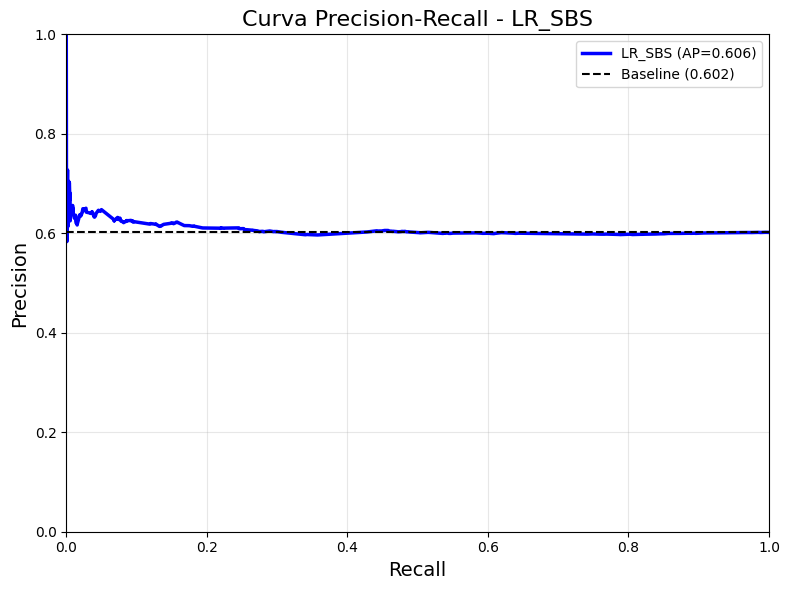

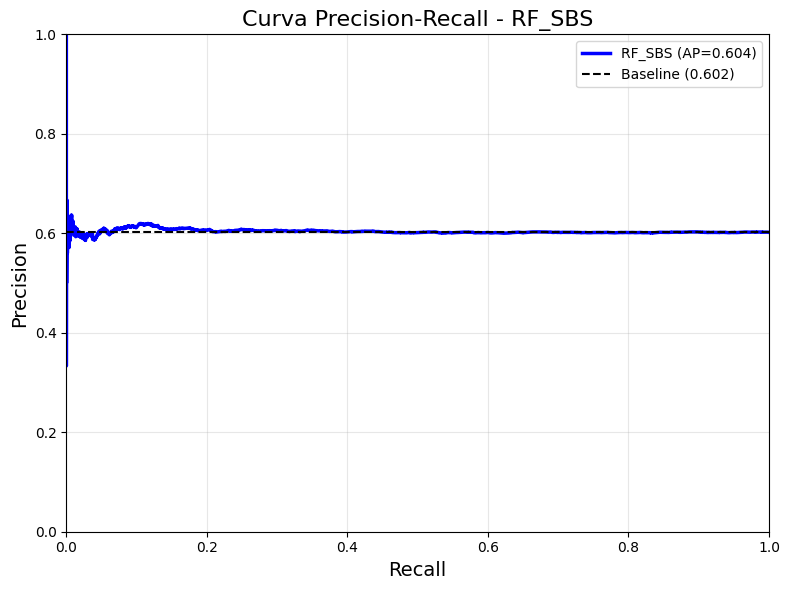

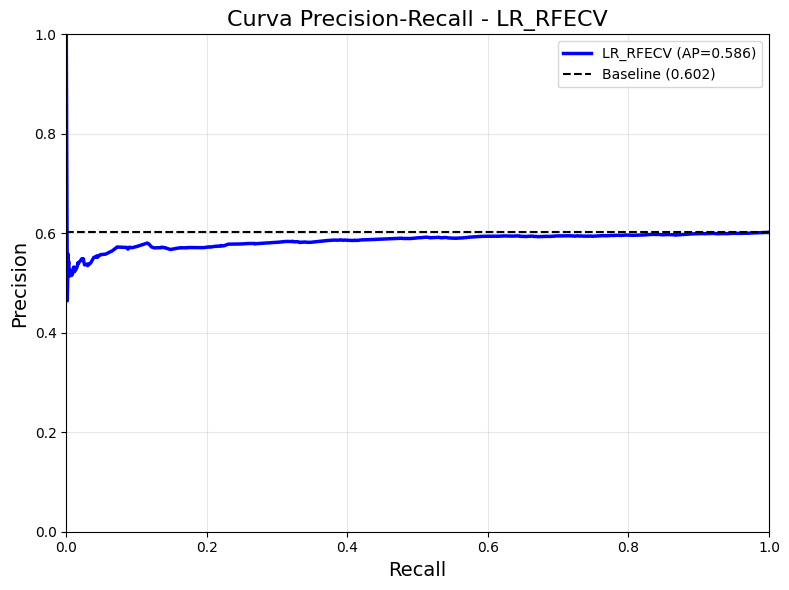

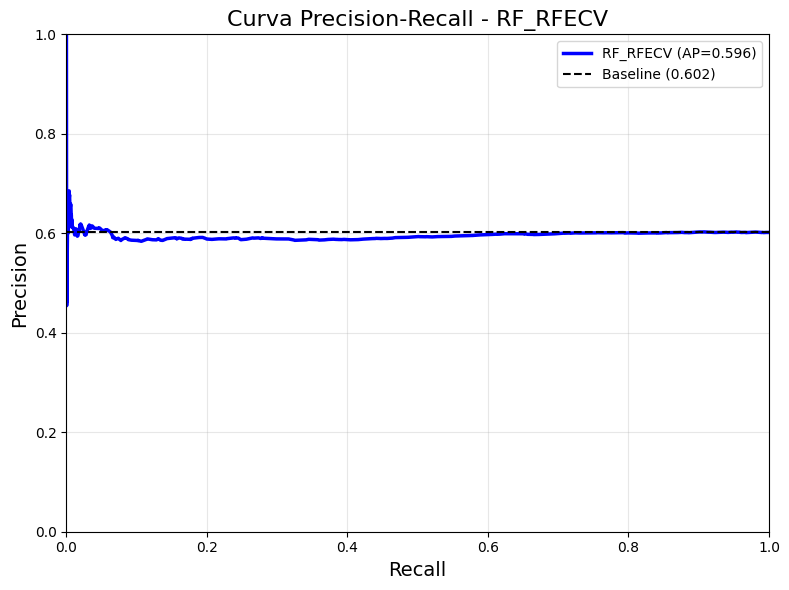

In [91]:
def plot_precision_recall_curves(X_train, X_val, y_train, y_val):
    # Definir modelos con los parámetros óptimos
    models = {
        'LR_SBS': LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000000, 
                                     penalty='l1', solver='saga', random_state=42),
        
        'RF_SBS': RandomForestClassifier(class_weight='balanced', max_depth=10, 
                                         min_samples_leaf=1, min_samples_split=5, 
                                         n_estimators=300, random_state=42),
        
        'LR_RFECV': LogisticRegression(C=1, class_weight='balanced', max_iter=1000000, 
                                       penalty='l2', solver='saga', random_state=42),
        
        'RF_RFECV': RandomForestClassifier(class_weight='balanced', max_depth=10, 
                                           min_samples_leaf=2, min_samples_split=5, 
                                           n_estimators=300, random_state=42)
    }
    
    # Definir conjuntos de características
    feature_sets = {
        'SBS_back': selected_features_SBS_back,
        'RFECV': selected_features_rfecv
    }
    
    # Procesar cada modelo
    for model_name, model in models.items():
        # Determinar qué conjunto de features usar
        if 'SBS' in model_name:
            features = feature_sets['SBS_back']
        else:
            features = feature_sets['RFECV']
        
        # Entrenar el modelo
        model.fit(X_train[features], y_train)
        
        # Obtener probabilidades
        if isinstance(model, LogisticRegression):
            y_proba = cross_val_predict(model, X_val[features], y_val, cv=3, method='decision_function')
        else:
            y_proba = cross_val_predict(model, X_val[features], y_val, cv=3, method='predict_proba')[:, 1]
        
        # Calcular curva precision-recall
        precision, recall, _ = precision_recall_curve(y_val, y_proba, pos_label=1)
        
        # Calcular AP (Average Precision)
        ap = average_precision_score(y_val, y_proba)
        
        # Crear una nueva figura para cada modelo
        plt.figure(figsize=(8, 6))
        plt.plot(recall, precision, color='b', linewidth=2.5, label=f"{model_name} (AP={ap:.3f})")
        
        # Configurar gráfico
        plt.title(f'Curva Precision-Recall - {model_name}', fontsize=16)
        plt.xlabel('Recall', fontsize=14)
        plt.ylabel('Precision', fontsize=14)
        
        # Añadir línea de baseline (proporción de clase positiva)
        no_skill = np.sum(y_val == 1) / len(y_val)
        plt.plot([0, 1], [no_skill, no_skill], 'k--', label=f'Baseline ({no_skill:.3f})')
        
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.0])  # Ajustar la escala del eje y entre 0 y 0.2
        plt.grid(True, alpha=0.3)
        plt.legend(loc='best')
        
        plt.tight_layout()
        plt.show()

# Ejecutar la función
plot_precision_recall_curves(X_train_processed, X_val_processed, y_train_processed, y_val_processed)


# 4. KAGGLE SUBMISSION CREATION

After selecting the best model with its optimal hyperparameters, it is now time to create the final CSV for submission in the Kaggle competition.

In [63]:
# Importing the test dataset provided in the DM II project materials

test_cancer_df = pd.read_csv('https://raw.githubusercontent.com/gascalero/DM_II_project/refs/heads/master/data/raw/patient_test_data.csv',
                         encoding='UTF-8',
                         index_col=0,
                         sep=',',
                         on_bad_lines='skip',
                         quoting=3)

test_cancer_df.head(1)

,Alcohol Consumption,Cancer Stage,Country,Date of Birth,Diabetes,Diabetes History,Diet Risk,Early Detection,Family History,Gender,...,Mortality Rate per 100K,Non Smoker,Obesity BMI,Physical Activity,Screening History,Smoking History,Transfusion History,Treatment Type,Tumor Size (mm),Urban or Rural
ID,,,,,,,,,,,,,,,,,,,,,
75036,Yes,Localized,UK,17-11-1947,No,No,Low,Yes,No,M,...,5.0,Yes,Overweight,Low,Regular,No,-,Combination,69.0,Urban


In [64]:
# Executing the preprocessing pipeline for the final test set

X_test_processed = preprocess_test_df(test_cancer_df, X_train_processed.columns, values_to_imput_cat, columns_to_delete, mode_train, stats_pre, binary_cols, numeric_cols, categorical_cols, encoders)

Dimension of test set before preprocessing: (75000, 34)
Dimension of test set after preprocessing: (75000, 48)


In [89]:
# Running the selected model into the test set
logistic_model = LogisticRegression(C= 0.1, class_weight= 'balanced', max_iter= 100000, penalty= 'l1', solver= 'saga')
logistic_model.fit(X_train_processed[selected_features_SBS_back], y_train_processed)
y_pred_logistic = logistic_model.predict(X_test_processed[selected_features_SBS_back])

In [90]:
# Creating the DataFrame for Kaggle submission
df_kaggle_lr = pd.DataFrame(y_pred_logistic, index=test_cancer_df.index)
df_kaggle_lr.replace({0: 'No', 1: 'Yes'}, inplace = True)
df_kaggle_lr.columns = ['Survival Prediction']
df_kaggle_lr.value_counts()

Survival Prediction
Yes                    45902
No                     29098
Name: count, dtype: int64

In [88]:
import os

# Exporting the DataFrame to a CSV file for submission
# Modify the file name as needed with the corresponding version number
output_dir = './data/Kaggle submissions'
os.makedirs(output_dir, exist_ok=True)  # Create the directory if it doesn't exist
df_kaggle_lr.to_csv(f'{output_dir}/DT_Group05_Version22.csv')

In [85]:
RF_kaggle = RandomForestClassifier(class_weight='balanced', max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=300 , random_state=42)
RF_kaggle.fit(X_train_processed[selected_features_SBS_back], y_train_processed)
y_pred_RF = logistic_model.predict(X_test_processed[selected_features_SBS_back])
#{'classifier__class_weight': 'balanced', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 300}

In [84]:
# Creating the DataFrame for Kaggle submission
df_kaggle_rf = pd.DataFrame(y_pred_RF, index=test_cancer_df.index)
df_kaggle_rf.replace({0: 'No', 1: 'Yes'}, inplace = True)
df_kaggle_rf.columns = ['Survival Prediction']
df_kaggle_rf.value_counts()

Survival Prediction
Yes                    45902
No                     29098
Name: count, dtype: int64

In [ ]:
import os

# Exporting the DataFrame to a CSV file for submission
# Modify the file name as needed with the corresponding version number
output_dir = './data/Kaggle submissions'
os.makedirs(output_dir, exist_ok=True)  # Create the directory if it doesn't exist
df_kaggle_rf.to_csv(f'{output_dir}/DT_Group05_Version21.csv')